In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1.

In [11]:
# transpose of a matrix
def trans(A):
    B = np.zeros((A.shape[1], A.shape[0]))
    for i in range(A.shape[0]):
        B[:,i] = A[i,:]
    return B    

In [12]:
a = np.array([[1, 2, 3],
              [4, 5, 6]], dtype = float)
print(f'A =\n{a}')
print(f'Calculated transpose =\n{trans(a)}')

# verification
print(f'Transpose using numpy =\n{np.transpose(a)}')

A =
[[1. 2. 3.]
 [4. 5. 6.]]
Calculated transpose =
[[1. 4.]
 [2. 5.]
 [3. 6.]]
Transpose using numpy =
[[1. 4.]
 [2. 5.]
 [3. 6.]]


# Problem 2.

In [13]:
def replace_diagonal(A, n):
    for i in range(A.shape[0]):
        A[i,i] = n
    return A            

In [14]:
a = np.array([[1, 2, 3],
              [4, 5, 6],
              [4, 5, 8]], dtype = float)
n = 0
print(f'A =\n{a}')
print(f'diagonal elements replaced to {n}\n{replace_diagonal(a, n)}')

# verification
np.fill_diagonal(a,n)
print(f'verification =\n{a}')

A =
[[1. 2. 3.]
 [4. 5. 6.]
 [4. 5. 8.]]
diagonal elements replaced to 0
[[0. 2. 3.]
 [4. 0. 6.]
 [4. 5. 0.]]
verification =
[[0. 2. 3.]
 [4. 0. 6.]
 [4. 5. 0.]]


# Problem 3.

In [19]:
# matrix multiplication
def mat_mul(A,B):
    if A.ndim == 1:
        A = A.reshape(1, -1)
    if B.ndim == 1:
        B = B.reshape(-1, 1)
    C = np.zeros((A.shape[0],B.shape[1]))
    if A.shape[1] != B.shape[0]:
        raise ValueError("Incompatible shapes for multiplication")
    
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            C[i,j] = np.sum(A[i,:]*B[:,j])
    return C        

In [22]:
a = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype = float)
b = np.array([0.1, 0.2, 0.3], dtype = float)
print(type(b),type(a))
print(a)
print(b)
print(mat_mul(a,b))
print(a@b)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
[0.1 0.2 0.3]
[[1.4]
 [3.2]
 [5. ]]
[1.4 3.2 5. ]


# Problem 4.

In [14]:
# Inverse of a 2*2 matrix
def inverse(A):
    det = A[0,0]*A[1,1] - A[0,1]*A[1,0]
    if det != 0:
        A[0,0],A[1,1],A[0,1],A[1,0] = A[1,1],A[0,0], - A[0,1], -A[1,0]
    return A

In [17]:
a = np.array([[4, 2],
              [4, 5]], dtype = float)
#
print(a)
b = inverse(a)
print(b)
np.linalg.inv(a)
print(f'verification =\n{a}')

[[4. 2.]
 [4. 5.]]
[[ 5. -2.]
 [-4.  4.]]
verification =
[[ 5. -2.]
 [-4.  4.]]


# Problem 5.

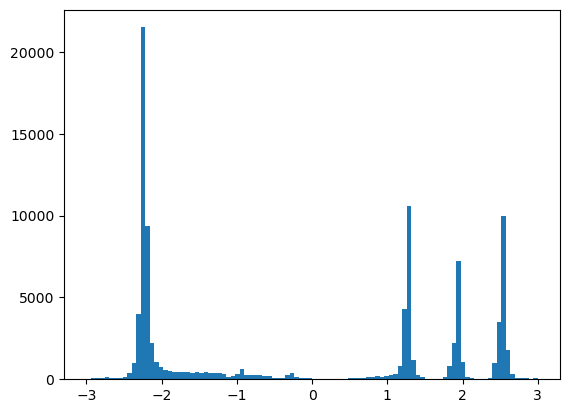

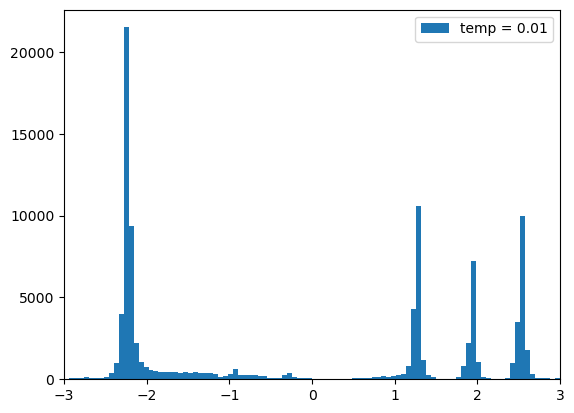

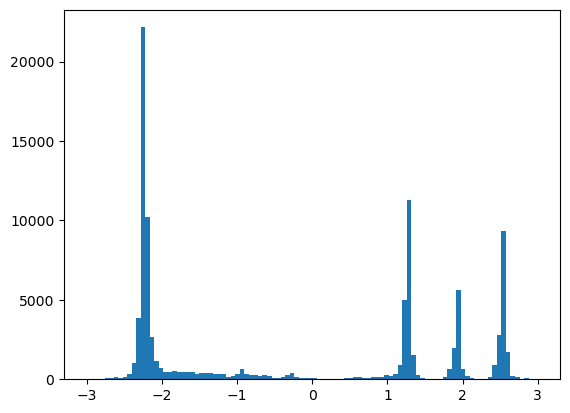

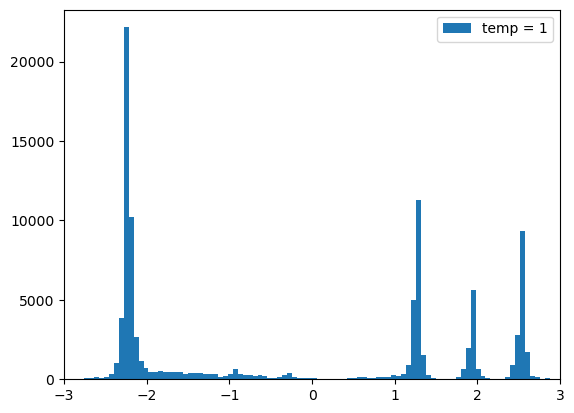

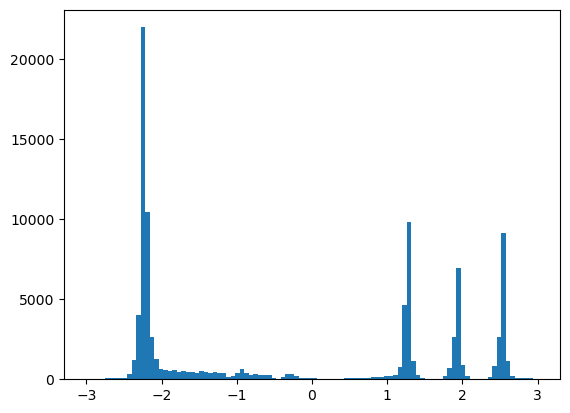

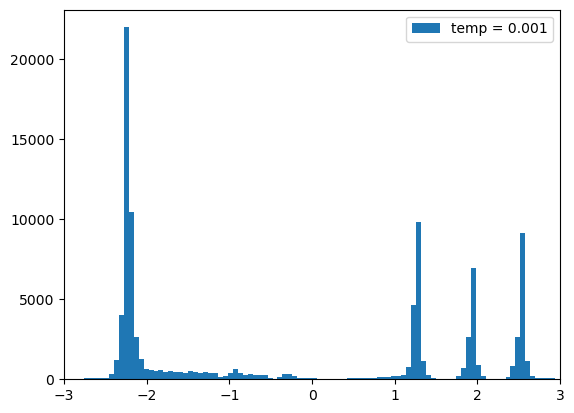

In [35]:
# defining the function
def f(x):
    return x**4 - 10*x**2 + 5*x + 3*np.sin(4*x) + 2*np.sin(9*x)

# parameters
n = 100000
b = 3000

temp = [0.01,1,0.001]


for T0 in temp:
    tau = 0.1
    
    # trajactory
    x_traj = []
    
    for j in range(b):
        # excepting a rendom point in range [-3,3]
        x_now = np.random.uniform(-3,3)
        for i in range(int(n/b)):
            Tn = T0/(1+(i/tau))
            #Tn = T0
            x_trial = x_now + 0.5*(2*np.random.rand()-1)
            
            if f(x_trial)<f(x_now):
                x_now = x_trial
            else:
                p = np.exp(-(f(x_trial)-f(x_now))/Tn)
                if np.random.rand() < p:
                    x_now = x_trial
            x_traj.append(x_now)
    counts, bin_edges, _ = plt.hist(x_traj, bins=100)
    peaks = []
    for i in range(1, len(counts)-1):
        if counts[i]>(n/200):
            if counts[i] > counts[i-1] and counts[i] > counts[i+1]:
                peaks.append(i)
    peaks = list(set(peaks))
    plt.figure()        
    plt.hist(x_traj, bins = 100, label = f'temp = {T0}')  
    plt.xlim(-3, 3)
    plt.legend()
    plt.show()

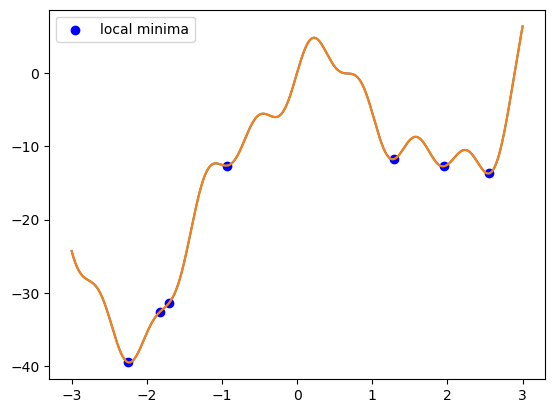

In [36]:
x = np.linspace(-3, 3, n)
plt.plot(x,f(x)) 
centers = [0.5*(bin_edges[i] + bin_edges[i+1]) for i in peaks]
plt.plot(x, f(x))
plt.scatter(centers, [f(c) for c in centers], color='b', label='local minima')
plt.legend()
plt.show()

# Problem 6.

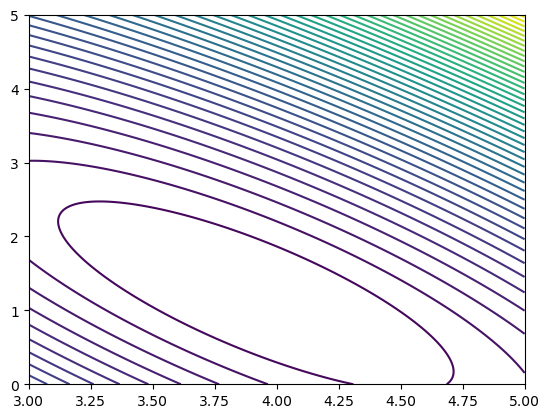

In [47]:
x = np.arange(1,11)
y = np.array([5.8, 9.5, 12.4, 15.9, 19.5, 23.8, 26.5, 29.9, 34.0, 37.2])
sigma = np.array([1.15, 1.90, 1.93, 2.38, 3.30, 3.45, 2.38, 5.53, 4.45, 7.60])
#plt.plot(x,y)

n = 200
w = np.array(1/(sigma**2))  
m_vals = np.linspace(3,5,n)
c_vals = np.linspace(0,5,n)
S = np.zeros((len(m_vals),len(c_vals)))
for i in range(len(m_vals)):
    for j in range(len(c_vals)):
        y_model = m_vals[i]*x+c_vals[j]
        S[i,j] = np.sum(w*((y-y_model)**2))
plt.contour(m_vals,c_vals, S, 50)        

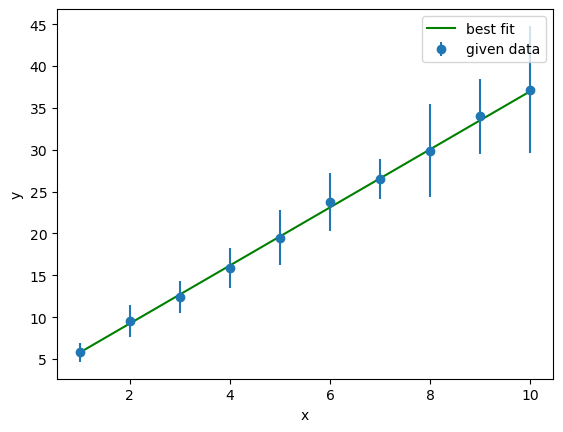

In [60]:
index = np.unravel_index(np.argmin(S),S.shape)
slope = m_vals[index[0]]
intercept = c_vals[index[1]]

xfit = np.linspace(np.min(x),np.max(x),n)
yfit = slope*xfit+intercept

plt.plot(xfit,yfit,color = 'g', label = 'best fit')
plt.errorbar(x, y, yerr=sigma,linestyle = ' ', marker = 'o', label = 'given data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [58]:
# Uncertainity in m and c
m_uncert = []
c_uncert = []
S_min = S[index]
for i in range(S.shape[0]):
    if np.any(S[i,:]<S[index]+2.3):
        m_uncert.append(m_vals[i])
    if np.any(S[:,i]<S[index]+2.3):
        c_uncert.append(c_vals[i])
mini_m = np.min(m_uncert)
max_m = np.max(m_uncert)
sigma_m = 0.5*(max_m - mini_m)
mini_c = np.min(c_uncert)
max_c = np.max(c_uncert)
sigma_c = 0.5*(max_c - mini_c)
print('uncertainity in m =', sigma_m)
print('uncertainity in c =', sigma_c)

uncertainity in m = 0.4522613065326633
uncertainity in c = 1.7713567839195983
